# moba `-L` tuning, stage 2a: wavelet strength (`--l1val`) — phantom v2, coronal plane

Stage 2a of the tuning plan, as approved by the researcher after stage 1
(`Recon_MOBA_Tuning_S1.ipynb`): **α_min = 0.2** with the per-slice residual-QC fallback, joint
l1-wavelet regularisation (no TV), and a sweep of the wavelet strength `--l1val`. The stage-1 maps
were judged *very noisy, with some artefacting*; this stage asks how much of the noise a stronger
wavelet removes and at what cost in bias, and characterises the artefacts.

**What `--l1val` does.** In each Newton step FISTA solves
½‖J·dx − r‖² + α_n·(l1val·‖W x_maps‖₁ + ‖ĉ‖²_Sobolev); `--l1val` scales only the joint wavelet
term on the three parameter maps (`moba_conf.l1val` → the wavelet prox). α_n (→ α_min) also weights
the coil penalty and decides stability (stage 1), so the two are decoupled: α_min stays 0.2.
Grid: l1val ∈ {0.5, 1, 2, 4} as full planes (1 = the stage-1 α_min 0.2 result), 8 as a screen.

Everything else as V2/stage 1: `moba -L -l1 -i 10 -C 100 -j 0.2 --sobolev_a 220`, fixed
noise-referenced scaling, slice-wise along the readout, T1 = 1/mean(R1*) over the two echo groups.
Data: **synthetic phantom v2 only**.

| step | what | section |
|---|---|---|
| 1 | screen: 13 readout slices × 2 echo groups per l1val; two failure modes | 3 |
| 2 | full planes: per-slice QC and the fallback | 4 |
| 3 | phantom numbers per l1val (bias vs ideal, noise), histograms | 5 |
| 4 | images for visual assessment | 6 |
| 5 | artefact analysis (noise vs systematic, the centre-slice dip) | 7 |
| 6 | decision | 8 |

## 1. Environment

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, uniform_filter

os.environ.setdefault('BART_TOOLBOX_PATH', str(Path('~/bart').expanduser()))
REPO = Path.cwd()
sys.path.insert(0, str(REPO / 'synth'))
sys.path.insert(0, str(REPO / 'moba_dev'))
import pipeline_utils as pu
from phantom import load_scans
import diag_slice as ds
import moba_plane as mp
import figures as F
import run_stage1 as S1
import run_stage2 as S2

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
warnings.filterwarnings('ignore', 'All-NaN slice')        # nanmedian over slices without WM

## 2. Configuration

In [2]:
PHANTOM_DIR = ds.PHANTOM_DIR
PROC_DIR = PHANTOM_DIR / 'moba'
PLANE = S2.PLANE
scans = load_scans(PHANTOM_DIR)[PLANE]
SP = pu.spacing_of(scans[pu.REF_TI_IDX]['info'])
truth = dict(np.load(PHANTOM_DIR / f'truth_{PLANE}.npz'))
head = truth['label'] >= 3
SCALING = S1.screen_scaling()
L1_ALL = sorted({1, *S2.L1_SCREEN})
L1_PLANES = sorted({1, *S2.L1_PLANES})
print('phantom', PHANTOM_DIR, '| fingerprint', ds.phantom_fingerprint(), '| alpha_min', S2.J, '| scaling', SCALING)
print('screen l1val', L1_ALL, '| full planes', L1_PLANES)
for v in L1_ALL:
    print(f'  l1val {v}: moba {S2.opts_l1(v)}')

phantom /root/work/phantom | fingerprint 7ff92781 | alpha_min 0.2 | scaling --scale_data 45.7869 --scale_psf 17.971312
screen l1val [0.5, 1, 2, 4, 8] | full planes [0.5, 1, 2, 4]
  l1val 0.5: moba -L -l1 -i 10 -C 100 --sobolev_a 220 -j 0.2 --l1val 0.5
  l1val 1: moba -L -l1 -i 10 -C 100 --sobolev_a 220 -j 0.2
  l1val 2: moba -L -l1 -i 10 -C 100 --sobolev_a 220 -j 0.2 --l1val 2
  l1val 4: moba -L -l1 -i 10 -C 100 --sobolev_a 220 -j 0.2 --l1val 4
  l1val 8: moba -L -l1 -i 10 -C 100 --sobolev_a 220 -j 0.2 --l1val 8


## 3. Screen: two different failure modes

13 readout slices × 2 echo groups per l1val (l1val 1 = the stage-1 screen at α_min 0.2). A slice
run is flagged when its raw residual exceeds 1.5 × its noise floor. The table classifies each
flagged run by two truth-free markers: the largest |M_ss| relative to the plane's typical value
(divergence inflates M_ss, see V2 section 7b) and the median residual of the whole screen.

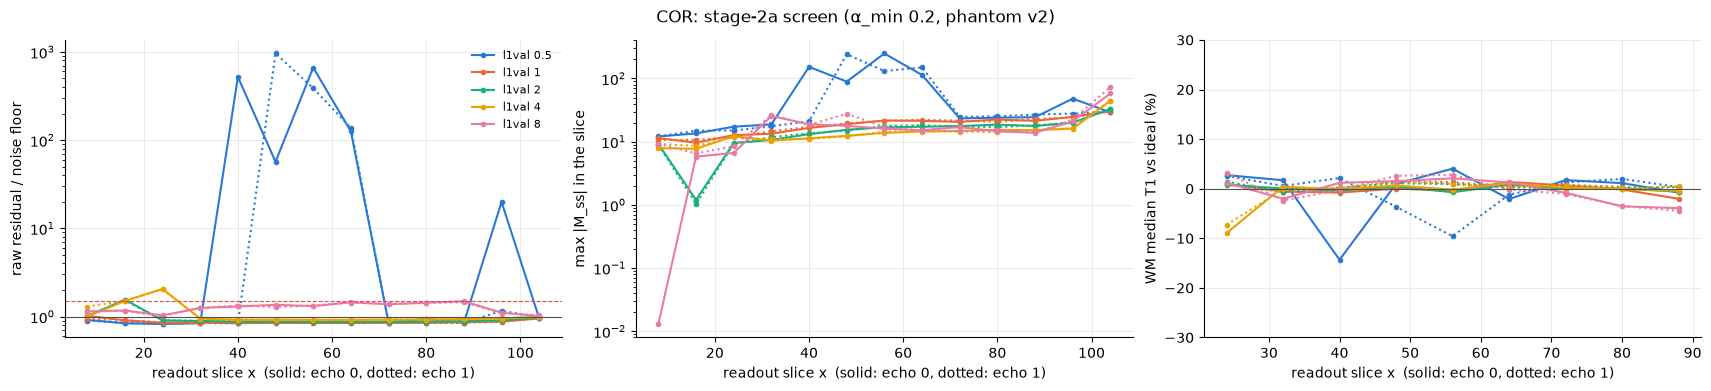

 l1val  flagged  res/noise median      max  flagged runs (res/noise, max|M_ss| / median of the screen)
   0.5     8/26              0.91   960.33  ['x=40 e0 (520.2, 6.1)', 'x=48 e0 (56.9, 3.6)', 'x=56 e0 (664.8, 10.0)', 'x=64 e0 (125.7, 4.6)', 'x=96 e0 (19.9, 1.9)', 'x=48 e1 (960.3, 9.7)', 'x=56 e1 (387.8, 5.3)', 'x=64 e1 (137.2, 6.0)']
     1     0/26              0.85     1.02  []
     2     2/26              0.89     1.56  ['x=16 e0 (1.6, 0.1)', 'x=16 e1 (1.5, 0.1)']
     4     4/26              0.93     2.06  ['x=16 e0 (1.5, 0.6)', 'x=24 e0 (2.1, 0.9)', 'x=16 e1 (1.5, 0.6)', 'x=24 e1 (2.1, 0.8)']
     8     0/26              1.29     1.49  []


In [3]:
scr = {v: (S1.screen(S2.J, SCALING) if v == 1 else S2.screen(v, SCALING)) for v in L1_ALL}
fig, ax = plt.subplots(1, 3, figsize=(17, 3.8), layout='constrained')
for (v, rr), col in zip(scr.items(), F.SERIES8):
    for e, ls in ((0, '-'), (1, ':')):
        r_e = [r for r in rr if r['e'] == e]
        x = [r['x'] for r in r_e]
        ax[0].semilogy(x, [r['final_res'] / r['noise_floor'] for r in r_e], 'o' + ls, ms=3, color=col,
                       label=f'l1val {v}' if e == 0 else None)
        ax[1].plot(x, [np.abs(r['maps'][..., 0]).max() for r in r_e], 'o' + ls, ms=3, color=col)
        ax[2].plot(x, [100 * (r['rows']['WM']['med'] / r['rows']['WM']['ideal'] - 1) if 'WM' in r['rows'] else np.nan
                       for r in r_e], 'o' + ls, ms=3, color=col)
ax[0].axhline(1, color='#52514e', lw=0.8); ax[0].axhline(S2.FLAG, color='#e34948', lw=0.8, ls='--')
ax[0].set_ylabel('raw residual / noise floor'); ax[1].set_ylabel('max |M_ss| in the slice'); ax[1].set_yscale('log')
ax[2].set_ylabel('WM median T1 vs ideal (%)'); ax[2].set_ylim(-30, 30); ax[2].axhline(0, color='#52514e', lw=0.8)
for a in ax:
    a.set_xlabel('readout slice x  (solid: echo 0, dotted: echo 1)'); F._style(a)
ax[0].legend(fontsize=8, frameon=False)
fig.suptitle(f'{PLANE}: stage-2a screen (α_min {S2.J}, phantom v2)'); plt.show()
print(f"{'l1val':>6s} {'flagged':>8s} {'res/noise median':>17s} {'max':>8s}  flagged runs (res/noise, max|M_ss| / median of the screen)")
for v, rr in scr.items():
    q = np.array([r['final_res'] / r['noise_floor'] for r in rr])
    mx = np.array([np.abs(r['maps'][..., 0]).max() for r in rr]); med = np.median(mx)
    bad = [f"x={r['x']} e{r['e']} ({qq:.1f}, {m / med:.1f})" for r, qq, m in zip(rr, q, mx) if qq > S2.FLAG]
    print(f'{v:6g} {len(bad):5d}/{len(rr)} {np.median(q):17.2f} {q.max():8.2f}  {bad}')

**Two failure modes.** *Too little regularisation* (l1val 0.5) gives the stage-1 **divergence**:
residual tens to hundreds × the noise floor, M_ss blown up, 20-30 % of brain voxels collapsed, at the
same slices as α_min 0.1 (x = 48-64, 96). *Too much regularisation* (l1val ≥ 2) gives
**over-regularisation** in the low-signal slices at the bottom of the head (x = 16, 24): residual
only 1.5-2 × the noise floor, no collapse, but the wavelet threshold removes the weak signal (M_ss
shrinks to 1-12) and T1 there is far off. At l1val 8 nothing is flagged but the *median* residual
rises to ~1.3 × the noise floor: every slice under-fits, i.e. the regulariser removes signal, not
only noise. The median residual is a usable, truth-free ceiling for the regularisation strength
(discrepancy principle): a well-regularised fit sits at ~0.85-0.95 × the noise floor here.

**Fallback policy (changed from stage 1).** Re-doing a flagged slice at α_min 0.3 is right for
divergence but makes an over-regularised slice worse. Stage 2 therefore replaces every flagged slice
by the **nearest setting towards the validated baseline that passes the QC in that slice**
(l1val 4 → 2 → 1, 2 → 1, 0.5 → 1; the baseline α_min 0.2, l1val 1 converged in all 224 slice runs
in stage 1). This is the discrepancy principle applied per slice on the computed grid: each slice
gets the strongest wavelet in the grid whose fit still explains the data to the noise level. (The
runner also computed the α_min 0.3 re-runs; they are not used.)

## 4. Full planes: per-slice convergence and the fallback

All 112 readout slices × 2 echo groups for each l1val; flagged slices (raw residual > 1.5 × noise
floor, per echo group) are replaced as described above (section 5 also lists the numbers without the
replacement).

l1val 0.5 echo 0:  16.5 min, res/noise median 0.92, max 5197.35; flagged  37: x = 18, 34-35, 40, 43, 45-65, 68-69, 75, 79, 91-92, 94-96, 102-103 -> l1val 1
l1val 0.5 echo 1:  16.2 min, res/noise median 0.91, max 47199.28; flagged  36: x = 19, 43-66, 68-69, 74-77, 92, 94-95, 102-103 -> l1val 1
l1val   1 echo 0:  23.8 min, res/noise median 0.86, max 1.10; flagged   0: none
l1val   1 echo 1:  23.1 min, res/noise median 0.86, max 1.10; flagged   0: none
l1val   2 echo 0:  16.7 min, res/noise median 0.89, max 2.99; flagged   3: x = 14-16 -> l1val 1
l1val   2 echo 1:  16.1 min, res/noise median 0.89, max 2.22; flagged   4: x = 13-16 -> l1val 1
l1val   4 echo 0:  16.3 min, res/noise median 0.94, max 2.17; flagged  13: x = 15-16 -> l1val 1, x = 13, 17-26 -> l1val 2
l1val   4 echo 1:  16.2 min, res/noise median 0.94, max 2.18; flagged  12: x = 15-16 -> l1val 1, x = 17-26 -> l1val 2


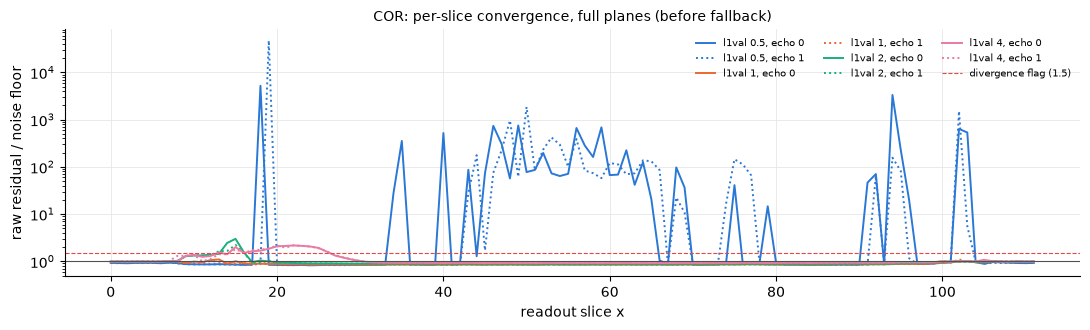

In [4]:
raw = {v: [mp.moba_recon(scans, e, PLANE, S2.opts_l1(v), PHANTOM_DIR, PROC_DIR)[0] for e in (0, 1)] for v in L1_PLANES}


def flagged(r):
    return r['final_res'] > S2.FLAG * r['noise_floor']


def with_fallback(v):
    '''Maps of setting v where each flagged slice is taken from the nearest grid setting towards
    l1val 1 that passes the QC there. Returns (maps per echo group, source l1val per slice and echo).'''
    steps = sorted((u for u in L1_PLANES if u != v and min(v, 1) <= u <= max(v, 1)), key=lambda u: abs(np.log(u / v)))
    out, src = [], []
    for e in (0, 1):
        m = raw[v][e]['maps'].copy(); s = np.full(m.shape[0], float(v)); bad = flagged(raw[v][e])
        for u in steps:
            ok = bad & ~flagged(raw[u][e])
            m[ok] = raw[u][e]['maps'][ok]; s[ok] = u; bad &= ~ok
        out.append(m); src.append(s)
    return out, src


def runs(xs):
    '''[13, 15, 16, 17] -> "13, 15-17"'''
    xs, out = list(xs), []
    for x in xs:
        if out and x == out[-1][1] + 1:
            out[-1][1] = x
        else:
            out.append([x, x])
    return ', '.join(f'{a}' if a == b else f'{a}-{b}' for a, b in out) or '-'


FB = {v: with_fallback(v) for v in L1_PLANES}
for v in L1_PLANES:
    for e in (0, 1):
        q = raw[v][e]['final_res'] / raw[v][e]['noise_floor']; src = FB[v][1][e]
        repl = ', '.join(f'x = {runs(np.flatnonzero(src == u))} -> l1val {u:g}' for u in sorted(set(src) - {v}))
        print(f"l1val {v:>3g} echo {e}: {float(raw[v][e]['runtime_s']) / 60:5.1f} min, res/noise median {np.median(q):.2f}, "
              f"max {q.max():.2f}; flagged {int(flagged(raw[v][e]).sum()):3d}: {repl or 'none'}")
F.slice_qc({f'l1val {v:g}': raw[v] for v in L1_PLANES}, f'{PLANE}: per-slice convergence, full planes (before fallback)'); plt.show()

## 5. Phantom numbers per l1val

T1 = 1/mean(R1*) of the two echo groups (after the fallback), `pu.evaluate_t1` (eroded tissue masks,
lesion masks ≥ half the peak partial-volume fraction). **Bias vs ideal** is the reconstruction's own
error; **robust SD** (1.4826 × MAD over the eroded mask, ms) measures the noise. The fraction of
the voxel error that is noise is estimated from the two echo groups (independent noise, shared
systematic error). For the 10 and 6 mm lesions (the 4 and 2 mm lesions hold 2 voxels each) the
lesion-WM **contrast** kept by the reconstruction and the voxel **CNR** (contrast / WM robust SD)
show the trade-off in one number each.

region                 n  ideal             l1 0.5             l1 1             l1 2             l1 4
WM                 70963  274.7    281.2 ( +2.4%)  276.9 ( +0.8%)  276.5 ( +0.6%)  276.8 ( +0.8%)
GM                  3750  339.3    343.0 ( +1.1%)  335.9 ( -1.0%)  328.2 ( -3.2%)  323.3 ( -4.7%)
lesion 1 (10 mm)      32  340.7    356.1 ( +4.5%)  343.0 ( +0.7%)  327.1 ( -4.0%)  317.1 ( -6.9%)
lesion 2 (6 mm)        7  336.2    310.6 ( -7.6%)  318.3 ( -5.3%)  322.6 ( -4.1%)  321.4 ( -4.4%)
lesion 3 (4 mm)        2  331.9    349.3 ( +5.2%)  349.3 ( +5.2%)  330.8 ( -0.3%)  311.7 ( -6.1%)
lesion 4 (2 mm)        2  283.5    309.8 ( +9.3%)  309.8 ( +9.3%)  306.7 ( +8.2%)  301.8 ( +6.5%)
lesion 5 (10 mm)      32  207.0    211.0 ( +1.9%)  214.1 ( +3.4%)  216.5 ( +4.6%)  224.5 ( +8.5%)
lesion 6 (6 mm)        7  206.9    219.2 ( +5.9%)  225.3 ( +8.9%)  230.9 (+11.6%)  239.3 (+15.7%)
lesion 7 (4 mm)        2  214.8    228.6 ( +6.4%)  228.6 ( +6.4%)  237.7 (+10.7%)  245.1 (+14.1%)
lesion 8 (2 mm) 

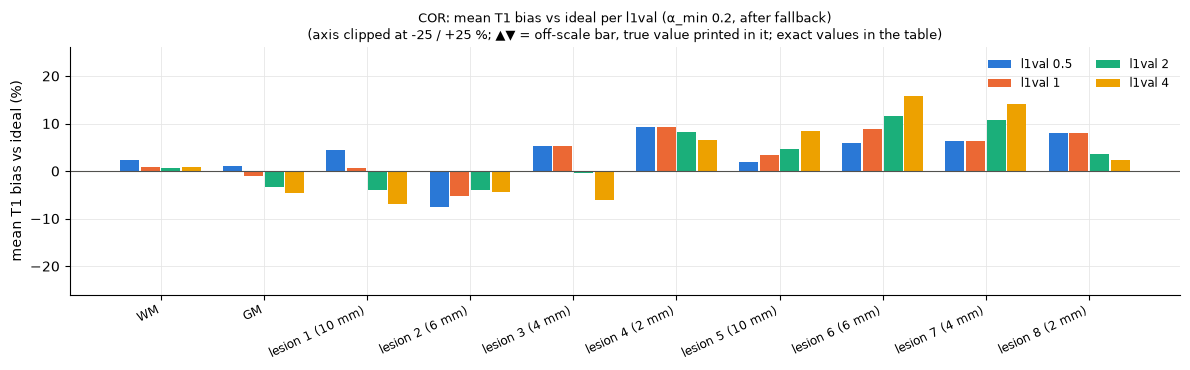

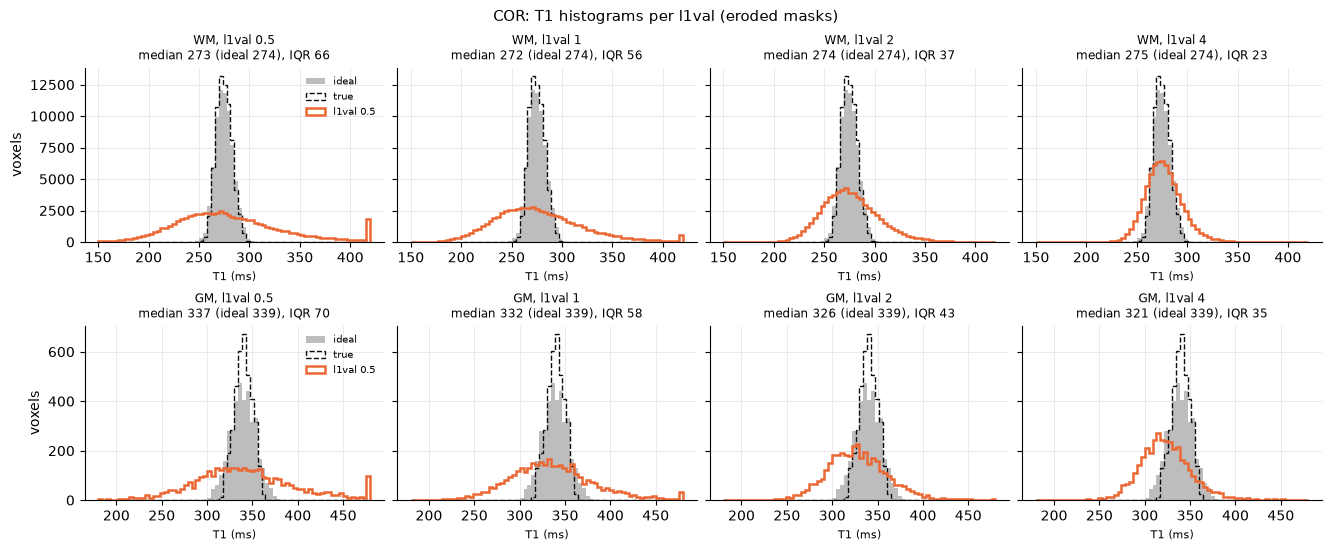

In [5]:
T1 = {f'l1val {v:g}': 1000 * mp.t1_from(FB[v][0], head) for v in L1_PLANES}
rows = {k: pu.evaluate_t1(t / 1000, truth) for k, t in T1.items()}
short = lambda k: k.replace('l1val ', 'l1 ')
cols = list(rows)
print(f"{'region':18s} {'n':>5s} {'ideal':>6s}  " + ''.join(f"{short(c):>17s}" for c in cols))
for i, r in enumerate(rows[cols[0]]):
    if r['region'] == 'CSF':
        continue
    print(f"{r['region']:18s} {r['n']:5d} {r['ideal_ms']:6.1f}  "
          + ''.join(f"{rows[c][i]['est_ms']:7.1f} ({rows[c][i]['bias_vs_ideal_pct']:+5.1f}%)" for c in cols))
print('\nwithout the fallback (flagged slices as reconstructed), bias vs ideal:')
for v in L1_PLANES:
    if all((FB[v][1][e] == v).all() for e in (0, 1)):
        continue
    rr = pu.evaluate_t1(mp.t1_from([r['maps'] for r in raw[v]], head), truth)
    print(f'   l1val {v:>3g}: ' + ', '.join(f"{r['region']} {r['bias_vs_ideal_pct']:+.1f}%" for r in rr
                                          if r['region'] in ('WM', 'GM', 'lesion 1 (10 mm)', 'lesion 5 (10 mm)')))
masks = F.tissue_masks(truth)
print('\nfailed voxels (R1* <= 0 or T1 > 1000 ms) in WM + GM after the fallback:',
      ', '.join(f"l1val {v:g}: {int(np.sum(~(T1[f'l1val {v:g}'] <= 1000) & (masks['WM'] | masks['GM'])))}" for v in L1_PLANES))
print()
rsd = {}
for name in ('WM', 'GM'):
    m = masks[name]
    print(f'{name}: ideal median {np.median(truth["T1_ideal_ms"][m]):.1f}')
    for v in L1_PLANES:
        t = T1[f'l1val {v:g}'][m]; t = t[np.isfinite(t)]
        te = [1000 / np.maximum(np.real(FB[v][0][e][..., 2]), 1e-3)[m] for e in (0, 1)]
        noise = 1.4826 * np.median(np.abs(te[0] - te[1])) / 2          # noise of the combined map
        rsd[name, v] = 1.4826 * np.median(np.abs(t - np.median(t)))
        print(f"   l1val {v:>3g}: median {np.median(t):6.1f}, robust SD {rsd[name, v]:5.1f} ms, of which noise ~{noise:5.1f} ms")
print('\nlesion contrast vs WM: (lesion mean − WM mean) as % of the ideal contrast; voxel CNR = |contrast| / WM robust SD')
reg = {r['region']: i for i, r in enumerate(rows[cols[0]])}
LES = [k for k in reg if k.startswith('lesion') and ('10 mm' in k or '6 mm' in k)]
print(f"{'l1val':>6s}  " + ''.join(f'{k:>24s}' for k in LES))
for v in L1_PLANES:
    rr = rows[f'l1val {v:g}']; w = rr[reg['WM']]
    print(f'{v:6g}  ' + ''.join(
        f"{100 * (rr[reg[k]]['est_ms'] - w['est_ms']) / (rr[reg[k]]['ideal_ms'] - w['ideal_ms']):10.0f} %, CNR {abs(rr[reg[k]]['est_ms'] - w['est_ms']) / rsd['WM', v]:4.2f}"
        for k in LES))
F.bias_bars(rows, f'{PLANE}: mean T1 bias vs ideal per l1val (α_min {S2.J}, after fallback)'); plt.show()
F.hist_by_setting(T1, truth, f'{PLANE}: T1 histograms per l1val (eroded masks)'); plt.show()

## 6. Images for visual assessment

Coronal in-plane slices (1.8 × 1.8 mm), rows = l1val (first row the ideal), shared window: the mid
slice and the slices through the lesion centres; the same as differences from the ideal; a zoom on
the lesion band; and the lesion panel.

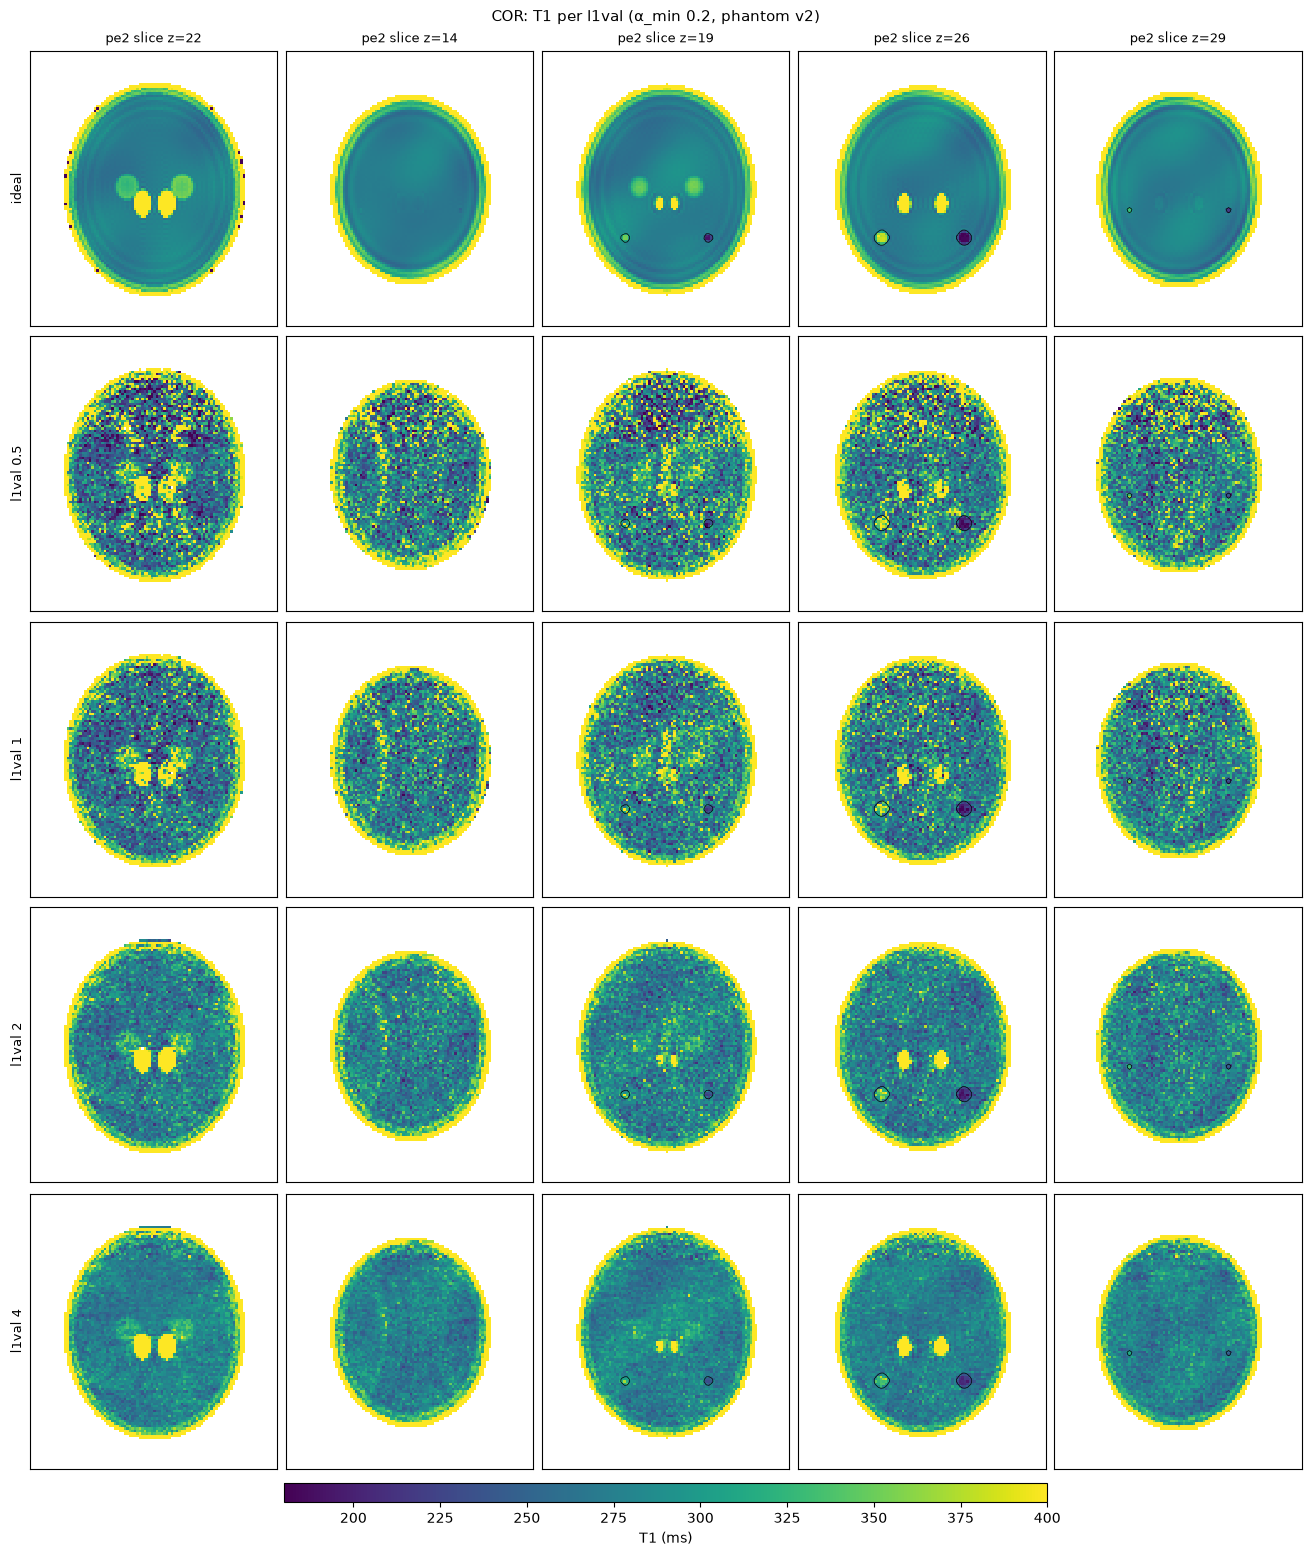

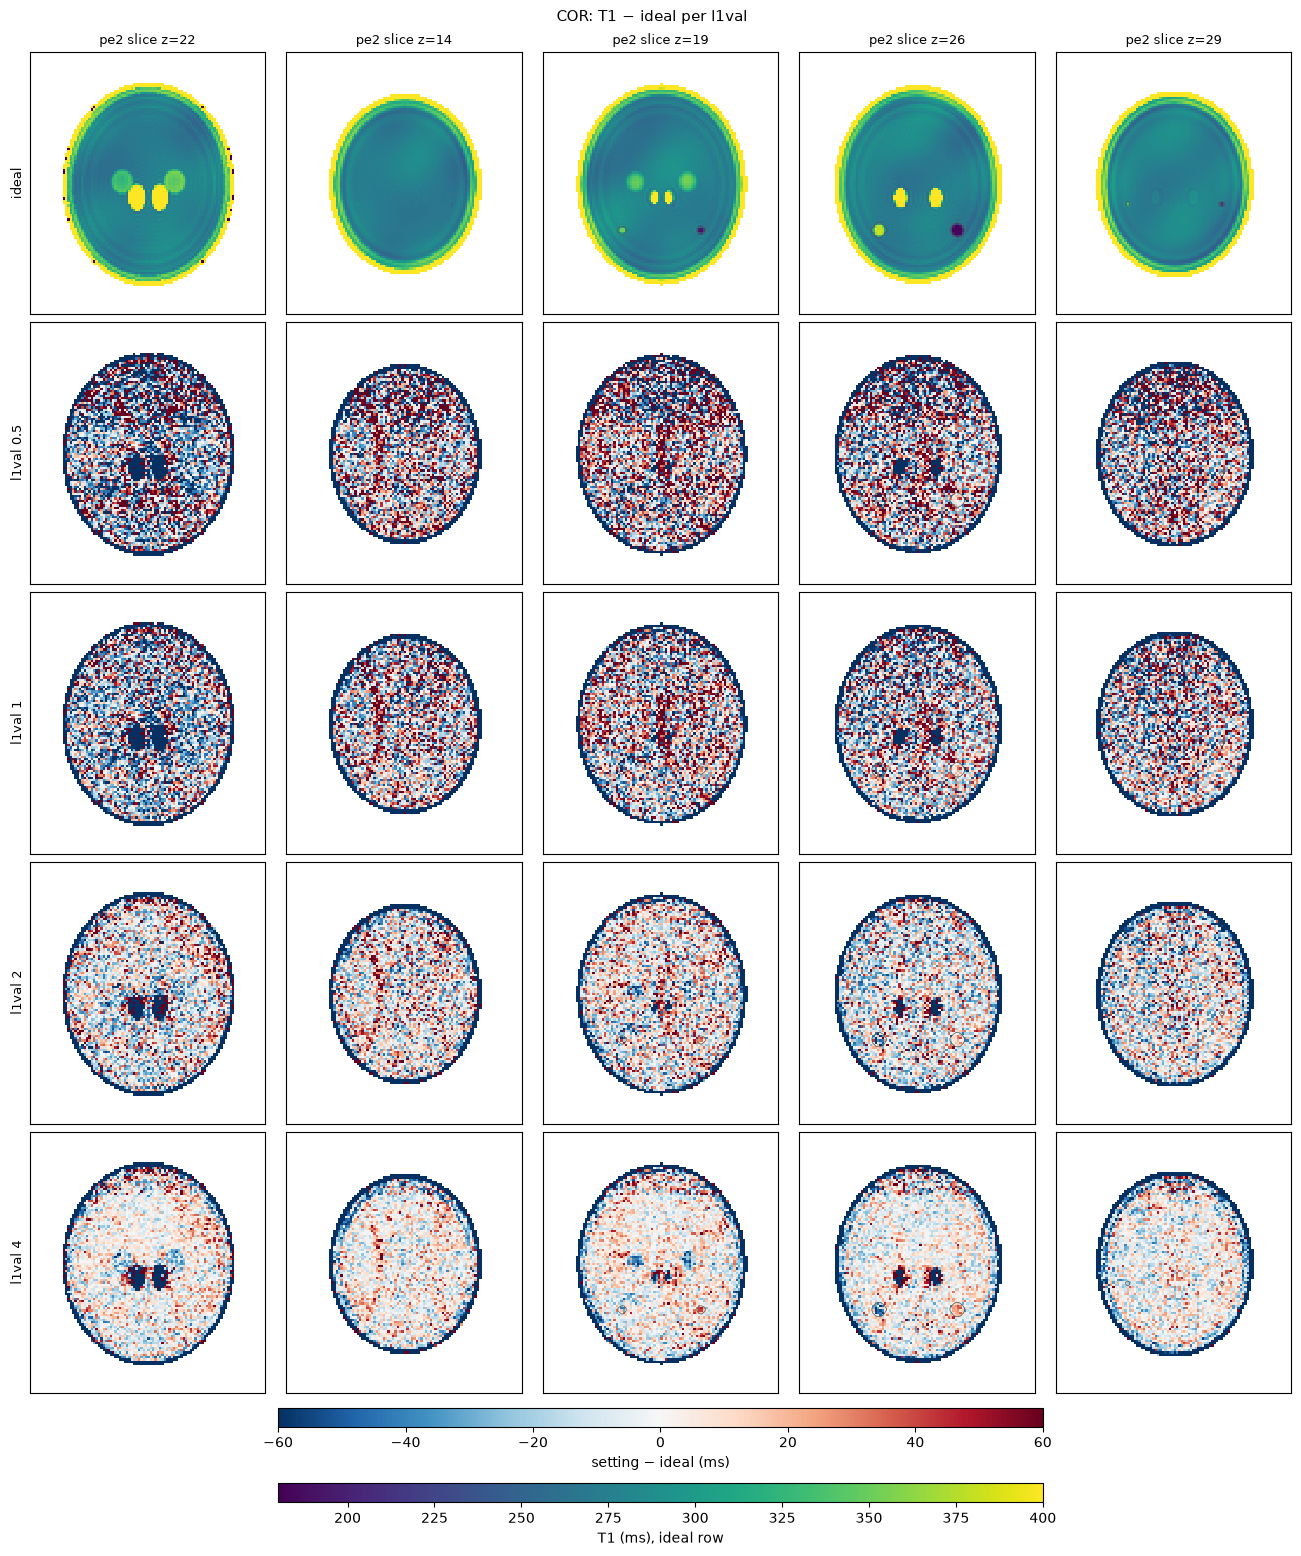

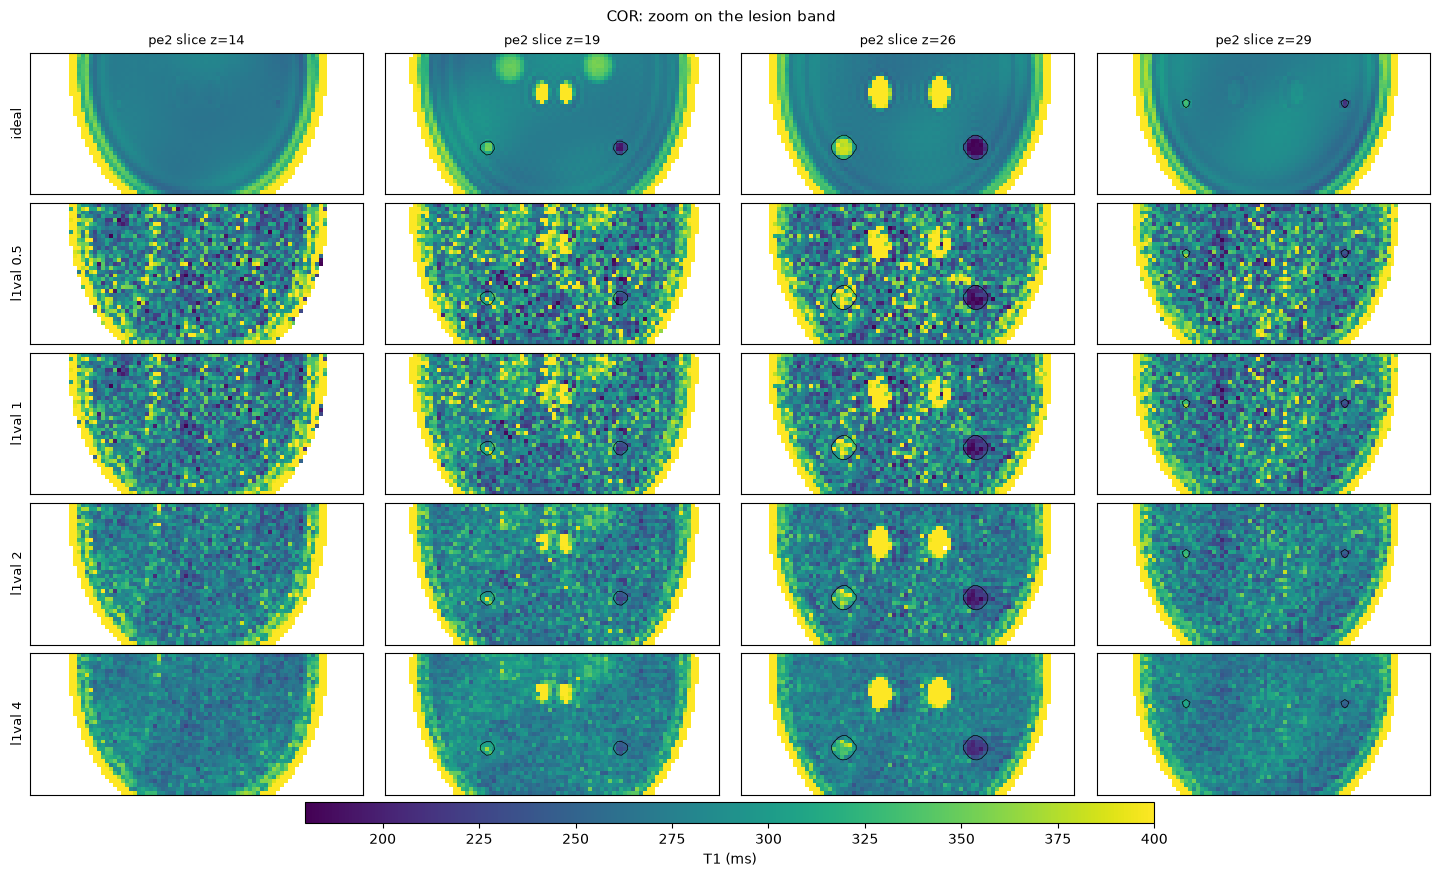

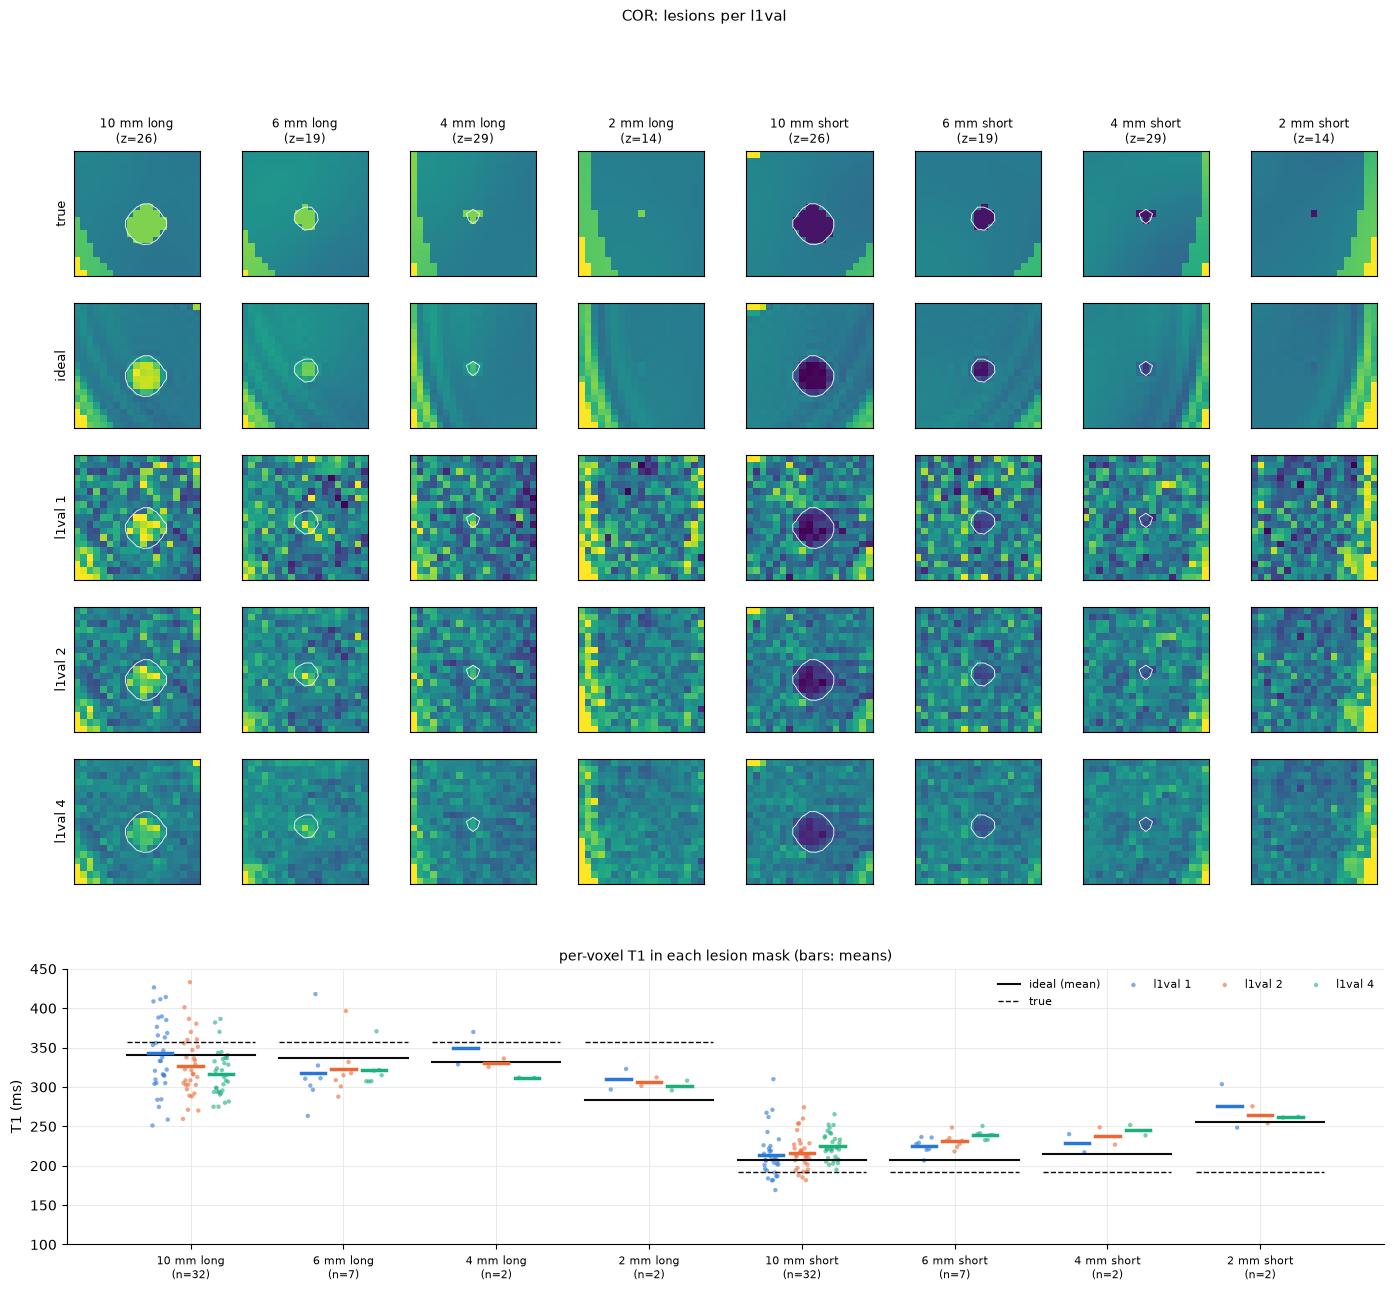

In [6]:
LZ = sorted(set(z for _, _, z in F.lesion_slices(truth)))
SL = [truth['label'].shape[2] // 2] + LZ
F.sweep_grid(T1, truth, SL, SP, f'{PLANE}: T1 per l1val (α_min {S2.J}, phantom v2)'); plt.show()
F.sweep_grid(T1, truth, SL, SP, f'{PLANE}: T1 − ideal per l1val', diff=True); plt.show()
xs_ = [x for x, _, _ in F.lesion_slices(truth)]
crop = (slice(min(xs_) - 12, max(xs_) + 13), slice(8, truth['label'].shape[1] - 8))
F.sweep_grid(T1, truth, LZ, SP, f'{PLANE}: zoom on the lesion band', crop=crop); plt.show()
sel = {k: T1[k] for k in ('l1val 1', 'l1val 2', 'l1val 4') if k in T1}
F.lesion_panel(sel, truth, SP, f'{PLANE}: lesions per l1val'); plt.show()

## 7. Artefact analysis

The researcher reported noise *and some artefacting*. The two echo groups carry independent noise
but share every systematic error, which separates the two: (a) the error of the combined map,
(b) the noise alone, (echo 0 − echo 1)/2, (c) the systematic part, (a) smoothed, (d) the per-voxel
errors of the two echo groups against each other, (e) the WM error per pe2 slice and (f) per (y, z)
averaged along the readout — anything repeated in every readout slice shows up there as a line.
Shown for l1val 1 (the stage-1 result) and the strongest stable setting.

l1val 1: echo-0/echo-1 voxel error correlation 0.07; voxels with |error| > 100 ms in echo 0: 8.7 %, of which also in echo 1 (same sign): 11 % (chance 9 %); too long: 85 %


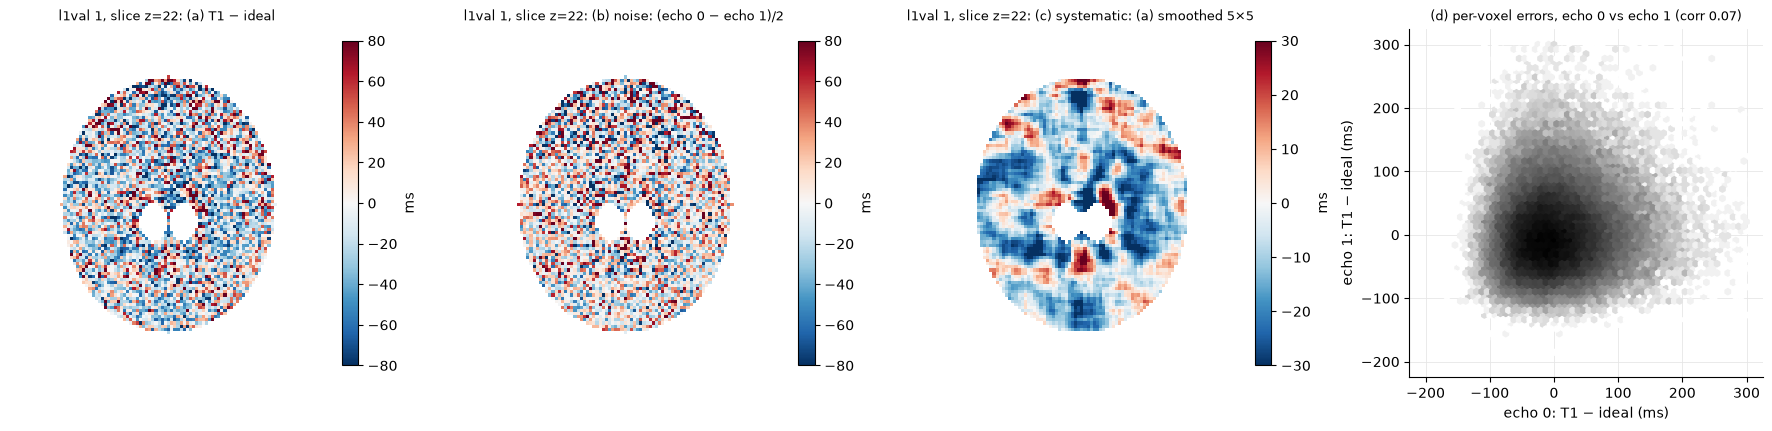

l1val 4: echo-0/echo-1 voxel error correlation 0.17; voxels with |error| > 100 ms in echo 0: 0.4 %, of which also in echo 1 (same sign): 5 % (chance 0 %); too long: 83 %


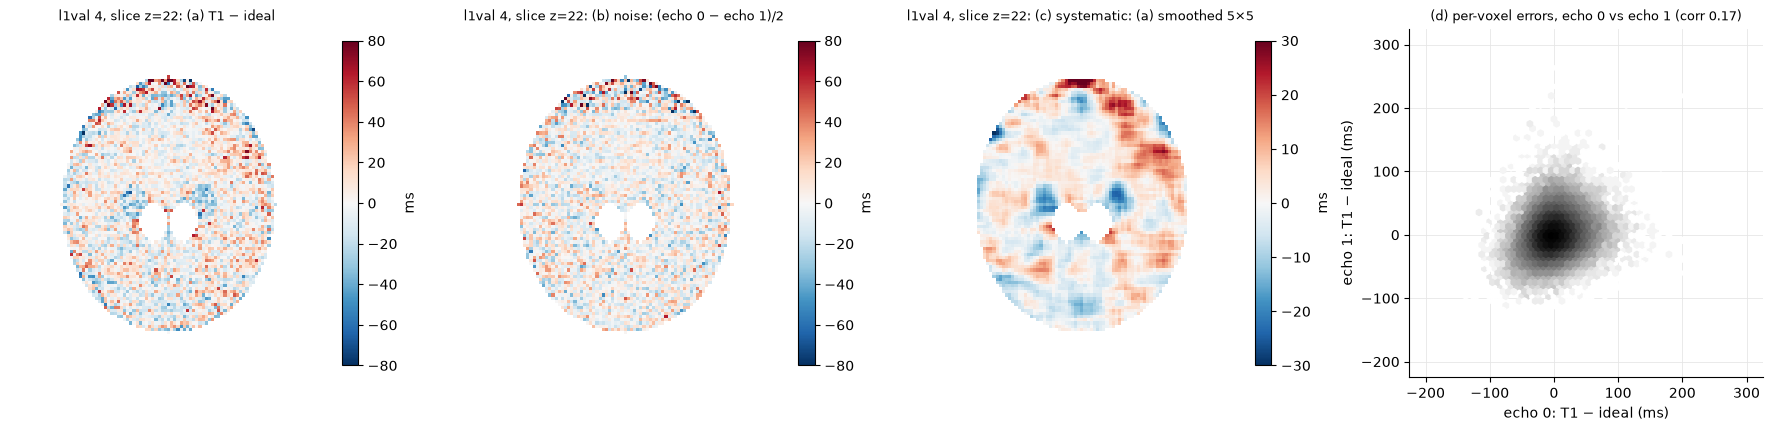

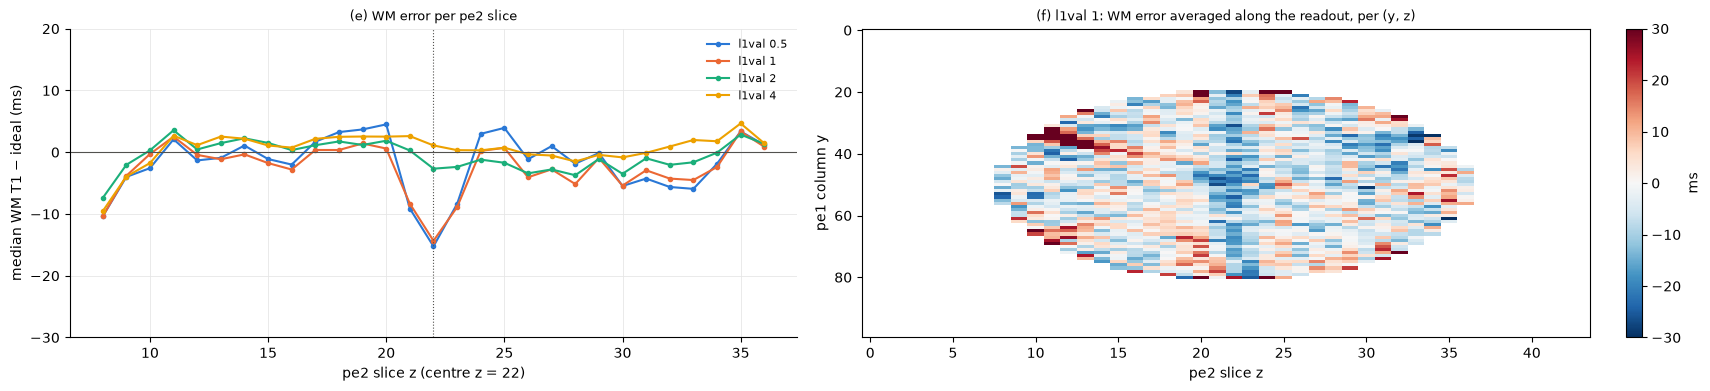

l1val 0.5: WM error at z=21-23 vs the other slices:  -9.8 ms; WM noise at z=21-23 46.5 ms vs 44.2 ms elsewhere
l1val   1: WM error at z=21-23 vs the other slices:  -8.8 ms; WM noise at z=21-23 37.1 ms vs 38.5 ms elsewhere
l1val   2: WM error at z=21-23 vs the other slices:  -1.9 ms; WM noise at z=21-23 23.7 ms vs 25.2 ms elsewhere
l1val   4: WM error at z=21-23 vs the other slices:  +0.4 ms; WM noise at z=21-23 13.7 ms vs 14.3 ms elsewhere


In [7]:
brain = binary_erosion(truth['label'] >= 4); wm = binary_erosion(truth['label'] == 5); ide = truth['T1_ideal_ms']


def sm(a, k=(5, 5, 1)):
    m = np.isfinite(a); den = uniform_filter(m.astype(float), k)
    return np.where(den > 0.5, uniform_filter(np.where(m, a, 0), k) / np.maximum(den, 1e-9), np.nan)


def per_z(Tmap):
    E = np.where(wm, Tmap - ide, np.nan)
    with np.errstate(all='ignore'):
        return np.nanmedian(E.transpose(2, 0, 1).reshape(E.shape[2], -1), axis=1)


for v in (1, max(L1_PLANES)):
    maps = FB[v][0]
    Te = [1000 / np.maximum(np.real(m[..., 2]), 1e-3) for m in maps]
    Tm = T1[f'l1val {v:g}']
    e0, e1 = (Te[0] - ide)[brain], (Te[1] - ide)[brain]
    ok = (np.abs(e0) < 400) & (np.abs(e1) < 400)
    h0 = np.abs(e0) > 100
    print(f'l1val {v:g}: echo-0/echo-1 voxel error correlation {np.corrcoef(e0[ok], e1[ok])[0, 1]:.2f}; '
          f'voxels with |error| > 100 ms in echo 0: {100 * h0.mean():.1f} %, of which also in echo 1 (same sign): '
          f'{100 * np.mean((np.abs(e1[h0]) > 100) & (np.sign(e1[h0]) == np.sign(e0[h0]))):.0f} % '
          f'(chance {100 * np.mean(np.abs(e1) > 100):.0f} %); too long: {100 * np.mean(e0[h0] > 0):.0f} %')
    z = 22
    fig, ax = plt.subplots(1, 4, figsize=(18, 4.2), layout='constrained')
    for a, (img, t, lim) in zip(ax[:3], ((Tm - ide, '(a) T1 − ideal', 80), ((Te[0] - Te[1]) / 2, '(b) noise: (echo 0 − echo 1)/2', 80),
                                         (sm(np.where(brain, Tm - ide, np.nan)), '(c) systematic: (a) smoothed 5×5', 30))):
        im = a.imshow(np.where(brain[:, :, z], img[:, :, z], np.nan), cmap='RdBu_r', vmin=-lim, vmax=lim, aspect=SP[0] / SP[1])
        a.set_title(f'l1val {v:g}, slice z={z}: {t}', fontsize=9); a.axis('off'); plt.colorbar(im, ax=a, fraction=0.046, label='ms')
    ax[3].hexbin(e0[ok], e1[ok], gridsize=60, cmap='Greys', bins='log', extent=(-200, 300, -200, 300))
    ax[3].set_xlabel('echo 0: T1 − ideal (ms)'); ax[3].set_ylabel('echo 1: T1 − ideal (ms)'); F._style(ax[3])
    ax[3].set_title(f'(d) per-voxel errors, echo 0 vs echo 1 (corr {np.corrcoef(e0[ok], e1[ok])[0, 1]:.2f})', fontsize=9)
    plt.show()

fig, ax = plt.subplots(1, 2, figsize=(17, 3.8), layout='constrained')
for v, col in zip(L1_PLANES, F.SERIES8):
    ax[0].plot(per_z(T1[f'l1val {v:g}']), 'o-', ms=3, color=col, label=f'l1val {v:g}')
ax[0].axvline(22, color='#52514e', lw=0.8, ls=':'); ax[0].axhline(0, color='#52514e', lw=0.8)
ax[0].set_xlabel('pe2 slice z (centre z = 22)'); ax[0].set_ylabel('median WM T1 − ideal (ms)'); ax[0].set_ylim(-30, 20)
ax[0].legend(fontsize=8, frameon=False); F._style(ax[0]); ax[0].set_title('(e) WM error per pe2 slice', fontsize=9)
E = np.where(wm, T1['l1val 1'] - ide, np.nan)
with np.errstate(all='ignore'):
    Eyz = np.nanmedian(E, axis=0)
im = ax[1].imshow(np.where(np.sum(np.isfinite(E), 0) >= 15, Eyz, np.nan), cmap='RdBu_r', vmin=-30, vmax=30, aspect='auto')
ax[1].set_xlabel('pe2 slice z'); ax[1].set_ylabel('pe1 column y'); plt.colorbar(im, ax=ax[1], fraction=0.03, label='ms')
ax[1].set_title('(f) l1val 1: WM error averaged along the readout, per (y, z)', fontsize=9)
plt.show()
ctr, oth = np.r_[21:24], np.r_[10:19, 26:34]
for v in L1_PLANES:
    pz = per_z(T1[f'l1val {v:g}'])
    Te = [1000 / np.maximum(np.real(m[..., 2]), 1e-3) for m in FB[v][0]]
    nz_ = [1.4826 * np.median(np.abs((Te[0] - Te[1])[:, :, z][wm[:, :, z]])) / 2 if wm[:, :, z].sum() > 200 else np.nan
           for z in range(wm.shape[2])]
    print(f'l1val {v:>3g}: WM error at z=21-23 vs the other slices: {np.nanmean(pz[ctr]) - np.nanmedian(pz[oth]):+5.1f} ms; '
          f'WM noise at z=21-23 {np.nanmean(np.take(nz_, ctr)):.1f} ms vs {np.nanmedian(np.take(nz_, oth)):.1f} ms elsewhere')

**What the artefacts are.**

1. **Bright single voxels (speckle) are noise, not artefacts.** The voxel errors of the two echo
   groups are nearly uncorrelated, and voxels far off in one echo group are far off in the other
   at close to chance level. Most of them are too *long*: T1 = 1/R1*, so symmetric noise in R1* becomes
   a long-T1 tail. They shrink with stronger regularisation (sections 5-6) and would average out
   further with more data (e.g. the 3-plane combination).
2. **A dip in the central coronal slices (z = 21-23)**: WM 9-15 ms low at l1val ≤ 1 (in every
   α_min of stage 1 and on both phantom versions; LLR shows a smaller one, −3.6 ms), much smaller at
   l1val 2 and gone at l1val 4 (panel e and the numbers above). The noise is *not* higher in those
   slices, so it is not an SNR effect; it is a systematic R1* offset that appears only with weak
   regularisation. The earlier hypothesis (z = 22 is where the coarsest level of moba's dyadic
   wavelet splits the 2× oversampled grid, and moba resets the random wavelet shifts to the same
   sequence in every Newton step and readout slice, `wavthresh_rand_state_set(prox, 1)` in
   `src/moba/iter_l1.c`) would predict a *larger* error with stronger thresholding, so it is less
   likely now; the mechanism is open. A shift test (move the object by two pe2 slices with a
   k-space phase ramp) would tell whether it is locked to the grid or to the anatomy.
3. **Lines along the readout** (vertical in these coronal maps; panel f): errors that repeat at the
   same (y, z) in consecutive readout slices. Each readout slice is an independent 2D problem with the
   same geometry, sampling and wavelet shift sequence, so a position-locked error repeats along the
   readout. They shrink with l1val.
4. CSF is far too short in every setting (5000 ms is beyond the measured TI range), including the
   CSF rim and the CSF at the top of the head (short bars at x = 13-14); outside the brain masks.

## 8. Result and decision (stage 2a)

**Phantom v2, coronal plane, α_min 0.2, joint l1-wavelet; only `--l1val` varies.** Every number
below is from the outputs above (the fallback replaces flagged slices as described in section 3).

### Stability: two failure modes

| l1val | screen: flagged (of 26) | full plane: flagged slices (echo 0 / 1, of 112) | median residual / noise floor | failure mode |
|---|---|---|---|---|
| 0.5 | 8 | **37 / 36** (x = 34-69, 74-79, 91-103) | 0.92 | divergence (up to 47 000 × the noise floor) |
| 1 | 0 | 0 / 0 | 0.86 | – |
| 2 | 2 | 3 / 4 (x = 13-16) | 0.89 | under-fit, top of the head |
| 4 | 4 | 13 / 12 (x = 13, 15-26) | 0.94 | under-fit, top of the head |
| 8 | 0 | – (screen only) | 1.29 (screen) | under-fit in every slice |

* **Weaker than 1 is not usable at α_min 0.2.** l1val and α_min both set how strongly the maps are
  regularised; stage 1 put α_min at the stability boundary for l1val 1, so l1val 0.5 crosses it:
  a third of the plane diverges, more than the screen suggested (8 of 26). Even after the
  replacement, 12 GM/WM voxels in converged slices have R1* ≤ 0 or T1 > 1000 ms (0 at l1val ≥ 1).
* **Stronger than 1 fails differently:** in the low-signal slices at the top of the head the
  wavelet removes signal along with the noise, the fit stays 1.5-2 × above the noise floor and
  T1 there is wrong (a smooth ramp unrelated to the anatomy, e.g. 170 → 2800 ms over 12 voxels
  of slice x = 15 at l1val 4). No collapse,
  no divergence, but the QC catches it.
* **The median residual is the global ceiling** (discrepancy principle: a fit should explain the data
  to the noise level, ≈ 1 × the noise floor): 0.86 → 0.89 → 0.94 → 1.29 for l1val 1 → 2 → 4 → 8.
  l1val 4 is the strongest setting that still fits the bulk of the plane; 8 under-fits everywhere.
* **The fallback works for both modes:** each flagged slice is taken from the nearest setting towards
  l1val 1 that passes there. At l1val 4: x = 13, 17-26 from l1val 2 and x = 15-16 from l1val 1. The
  α_min 0.3 re-runs the runner also made would have failed: they stay diverged at l1val 0.5 (up to
  379 × the floor) and make the under-fit worse at l1val 2 (up to 3.6 ×).

### What the wavelet strength buys (after the fallback)

| | ideal | l1val 0.5 | l1val 1 (stage 1) | l1val 2 | l1val 4 |
|---|---|---|---|---|---|
| WM mean T1 bias | 274.7 ms | +2.4 %¹ | +0.8 % | +0.6 % | +0.8 % |
| GM mean T1 bias | 339.3 ms | +1.1 % | −1.0 % | −3.2 % | **−4.7 %** |
| WM robust SD (noise part) | – | 48.4 (45.0) ms | 40.9 (38.2) | 26.9 (24.5) | **17.0 (14.1)** |
| GM robust SD (noise part) | – | 51.1 (46.6) ms | 42.9 (38.3) | 32.0 (27.1) | 25.9 (20.2) |
| lesion 10 mm long T1 | 340.7 ms | +4.5 %² | +0.7 % | −4.0 % | −6.9 % |
| lesion 6 mm long | 336.2 ms | −7.6 %² | −5.3 % | −4.1 % | −4.4 % |
| lesion 10 mm short T1 | 207.0 ms | +1.9 %² | +3.4 % | +4.6 % | +8.5 % |
| lesion 6 mm short | 206.9 ms | +5.9 %² | +8.9 % | +11.6 % | +15.7 % |
| lesion-WM contrast kept, 10 mm long / short | 100 % | 114 / 104 %² | 100 / 93 % | 77 / 89 % | 61 / 77 % |
| voxel CNR, 10 mm long / short | – | 1.55 / 1.45 | 1.62 / 1.53 | 1.88 / 2.23 | **2.37 / 3.07** |
| voxel CNR, 6 mm long / short | – | 0.61 / 1.28 | 1.01 / 1.26 | 1.71 / 1.69 | **2.62 / 2.20** |
| WM dip at the central slices z = 21-23 | – | −9.8 ms | −8.8 ms | −1.9 ms | +0.4 ms |

¹ inflated by the 12 failed voxels (the WM median is 272.9 ms). ² most of the lesion band
(x = 62-79) diverged at 0.5 and was replaced by l1val 1 slices, so these are partly l1val 1 values.
The 4 and 2 mm lesions hold 2 voxels each (±5-10 % is noise); they are in the table above but not
used here.

* **Noise falls steeply, WM accuracy does not change:** WM robust SD 40.9 → 26.9 → 17.0 ms
  (−34 %, −58 %), almost all of it noise; WM bias stays at +0.6-0.8 %. The speckle (single voxels
  > 100 ms off: 8.7 % of brain voxels at l1val 1, 0.4 % at l1val 4) is what made the stage-1 maps
  look "very noisy"; it is noise, not an artefact (section 7, point 1).
* **The cost is contrast in small and thin structures:** GM (a thin ribbon after erosion, mixed with
  WM by the smoothing) −1.0 → −3.2 → −4.7 %; lesions are pulled towards WM (10 mm lesions keep
  77-89 % of their contrast at l1val 2, 61-77 % at 4; short-T1 lesions are hit harder: +8.5 % and
  +15.7 % at l1val 4 for 10 and 6 mm).
* **But noise falls faster than contrast:** the voxel CNR of every ≥ 6 mm lesion rises
  monotonically with l1val (1.0-1.6 at l1val 1, 1.7-2.2 at 2, 2.2-3.1 at 4). For *seeing* lesions
  stronger is better up to 4; for *measuring* lesion T1, weaker is better. The pre-agreed stage-2
  rule (lowest lesion bias with WM/GM within ± 2 %) picks l1val 1; it was written before noise was
  identified as the main problem.
* **l1val 0.5 buys nothing:** noisier, a third of the plane diverged, failed voxels.

### Artefacts (section 7)

1. **Speckle = noise** (see above): echo-group voxel errors correlate at 0.07 (l1val 1); the far-off
   voxels coincide between the echo groups at close to chance level (11 vs 9 %); 85 % are too long (T1 = 1/R1*
   turns symmetric R1* noise into a long tail). Stronger wavelet removes it.
2. **Central-slice dip (z = 21-23):** −9 to −10 ms at l1val ≤ 1, −1.9 ms at 2, gone at 4. The noise
   is *not* higher in those slices (37.1 vs 38.5 ms at l1val 1), so low SNR is ruled out; it is a
   systematic R1* offset (+0.2 s⁻¹ median at z = 22) that appears only with weak regularisation.
   My earlier hypothesis (wavelet grid locked to the centre + the fixed shift sequence) predicts a
   larger error with *stronger* thresholding, the opposite of what is seen, so it is now less
   likely. It is not excluded and the mechanism is open. At l1val ≥ 2 it is ≤ 2 ms.
3. **Lines along the readout** (vertical in these coronal maps): errors that repeat at the same
   (y, z) position in consecutive readout slices, e.g. z = 14, y = 38: +34 ms median over 40
   readout slices at l1val 1, +12 ms at l1val 4. Each readout slice is an independent 2D problem
   with the same geometry, the same sampling and the same wavelet shift sequence (moba resets the
   random-shift state to 1 at every Newton step, `src/moba/iter_l1.c`), so a position-locked error
   repeats along the readout. They shrink with l1val, like the dip. Not analysed further.
4. **Edges:** CSF (ventricles, the CSF rim, the top-of-head CSF at x = 13-14) is far too short in
   every setting (true 5000 ms is beyond the measured TI range); this is outside the brain masks.
   At l1val 4 deep GM next to the ventricles is pulled down (blue halos in the difference maps:
   smoothing across the ventricle edge).

### Decision (for the researcher)

**My recommendation is l1val 4 with the per-slice fallback (4 → 2 → 1)** as the working point
for the next stages, because it addresses the problem raised (noise and artefacting):
- the noise falls 2.7×;
- the speckle (8.7 → 0.4 %) and the central-slice dip are gone;
- lesion CNR is the highest in the grid;
- WM is unbiased;
- the plane still fits to the noise level (median 0.94).

It **violates the pre-agreed ±2 % GM criterion** (−4.7 %), and lesion T1 values are pulled towards
WM by 4-16 %. If lesion and GM T1 *values* are the endpoint, **l1val 2** is the compromise:
- noise falls by a third;
- GM bias is −3.2 %;
- lesions are within −4 / +12 %;
- only 3-4 slices need the fallback.

The final choice is yours from the maps and histograms (section 6).

Caveats:
- One noise realisation, one plane, a phantom whose SNR may differ from the scanner's.
- On real data the per-slice QC decides where l1val 4 under-fits; that safeguard comes with the
  fallback.

### Next (proposals, await approval)

* **Contrast recovery at the chosen l1val:** moba's wavelet is a *joint* group threshold over
  (M_ss, M0', R1*) (`COEFF_FLAG`, `src/moba/iter_l1.c`), so the numerical scale of R1* sets how much
  its own edges count. Scaling the TI axis by k (R1* → R1*/k; `diag_slice.run(ti_scale=k)`, the
  -L model ignores `--other pscale`) shifts that weight. Screen k ∈ {0.5, 2} at l1val 4 plus the
  lesion slab (≈ 2 × 13 min ≈ 25 min).
  - Tests whether R1* edges (lesions, GM) can be kept while M_ss/M0' stay smooth.
  - Decision: adopt k if lesion contrast rises with ≤ 10 % more WM noise and no new flagged slices.
  - Uncertain: k also changes the conditioning of the Gauss-Newton steps, so stability must be
    re-checked.
* **Grid- vs anatomy-locked errors (dip, lines):** shift the object by 2 pe2 and 2 pe1 voxels before
  reconstruction (k-space phase ramp), reconstruct the 13 screen slices at l1val 1 (≈ 5 min) and see
  whether the dip and the lines move with the grid or with the anatomy. Optionally, a BART build
  with a per-slice random-shift seed. Low priority if l1val ≥ 2 is chosen.
* **Stage 3 (iteration counts)** as planned, at the chosen l1val: `-i` ∈ {8, 10, 12, 14} ×
  `-C` ∈ {50, 100} on the lesion slab (≈ 70 min).
* LLR on phantom v2 for a side-by-side (≈ 35 min) is still open.